In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ibrahimshahrukh/tesla-stock-price-historical-dataset-2010-2025/tesla_stock_data_2010_2025.csv


# Tesla Stock Market Analysis
**Goal:** Analyze historical Tesla stock prices (2010–2025)  
**Focus:** Trends, volatility, and data storytelling using Python (Pandas, Matplotlib)

In [2]:
# Load Data
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/ibrahimshahrukh/tesla-stock-price-historical-dataset-2010-2025/tesla_stock_data_2010_2025.csv')

df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change,Price_Change_Percent,MA_7,MA_30,MA_90,Volatility_7d,Year,Month,Day_of_Week,Quarter
0,2010-06-29,1.27,1.67,1.17,1.59,281494500,NaN,0.50,0.32,25.20,NaN,NaN,NaN,NaN,2010,6,Tuesday,2
1,2010-06-30,1.72,2.03,1.55,1.59,257806500,0.0000,0.48,-0.13,-7.56,NaN,NaN,NaN,NaN,2010,6,Wednesday,2
2,2010-07-01,1.67,1.73,1.35,1.46,123282000,-0.0818,0.38,-0.21,-12.57,NaN,NaN,NaN,NaN,2010,7,Thursday,3
3,2010-07-02,1.53,1.54,1.25,1.28,77097000,-0.1233,0.29,-0.25,-16.34,NaN,NaN,NaN,NaN,2010,7,Friday,3
4,2010-07-06,1.33,1.33,1.06,1.07,103003500,-0.1641,0.27,-0.26,-19.55,NaN,NaN,NaN,NaN,2010,7,Tuesday,3


In [3]:
#Clean & Prepare Data
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Check missing values
df.isnull().sum()

Date                     0
Open                     0
High                     0
Low                      0
Close                    0
Volume                   0
Daily_Return             1
Price_Range              0
Price_Change             0
Price_Change_Percent     0
MA_7                     6
MA_30                   29
MA_90                   89
Volatility_7d            7
Year                     0
Month                    0
Day_of_Week              0
Quarter                  0
dtype: int64

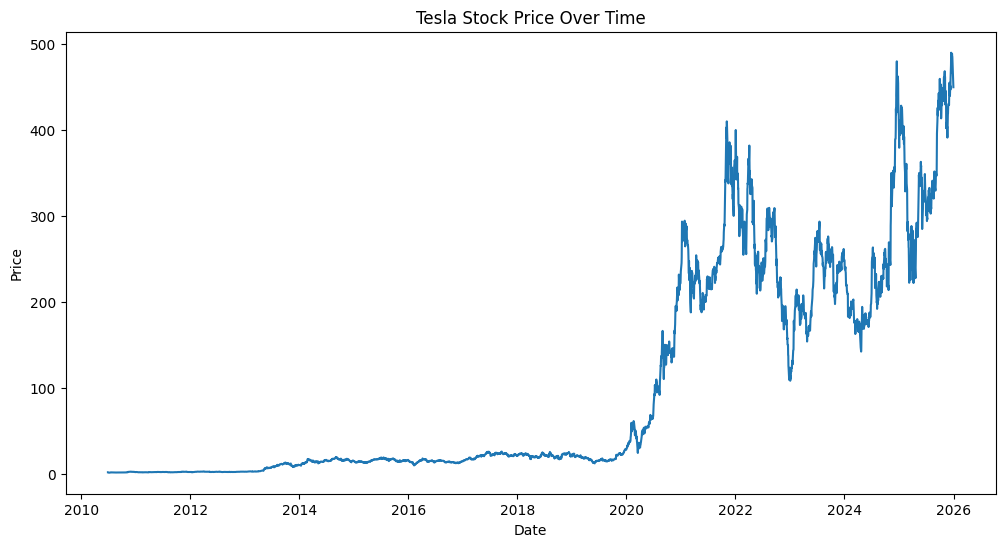

In [4]:
#Plot Stock Price (TREND)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title('Tesla Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()


## Trend Insights
- Tesla shows strong growth after 2020, reflecting market expansion and company performance.
- Sharp drops correspond to major market events (e.g., 2020 pandemic dip).

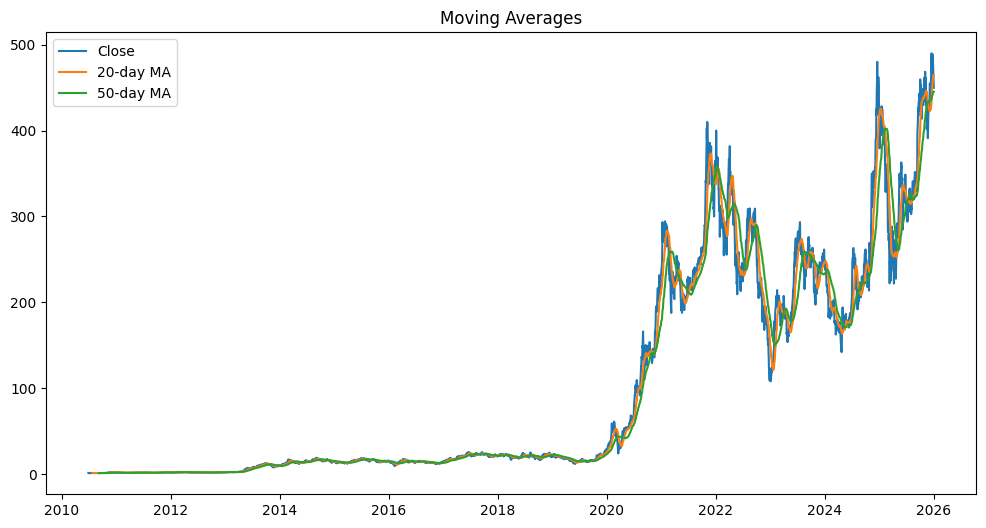

In [5]:
#Moving Averages (TREND SIGNALS)
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA20'], label='20-day MA')
plt.plot(df['Date'], df['MA50'], label='50-day MA')

plt.legend()
plt.title('Moving Averages')
plt.show()

## Moving Average Insights
- When the 20-day MA crosses above the 50-day MA (Golden Cross), it signals a potential upward trend.
- When the 20-day MA crosses below the 50-day MA (Death Cross), it signals a potential downward trend.

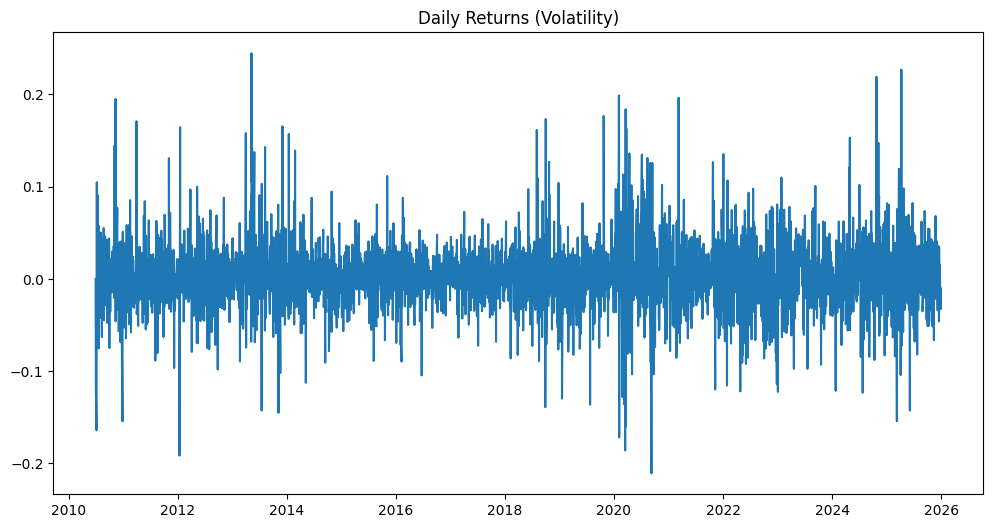

In [6]:
#Volatility
df['Returns'] = df['Close'].pct_change()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Returns'])
plt.title('Daily Returns (Volatility)')
plt.show()

## Volatility Insights
- Daily returns fluctuate strongly, indicating periods of instability.
- High spikes often correlate with news or earnings reports.